<a href="https://colab.research.google.com/github/ajimotirofiat2-lgtm/AVCAD-ASSIGNMENT/blob/main/Rofiat_EXERCISE6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [ ]:
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')

--- Visual check for continuous environmental variables ---


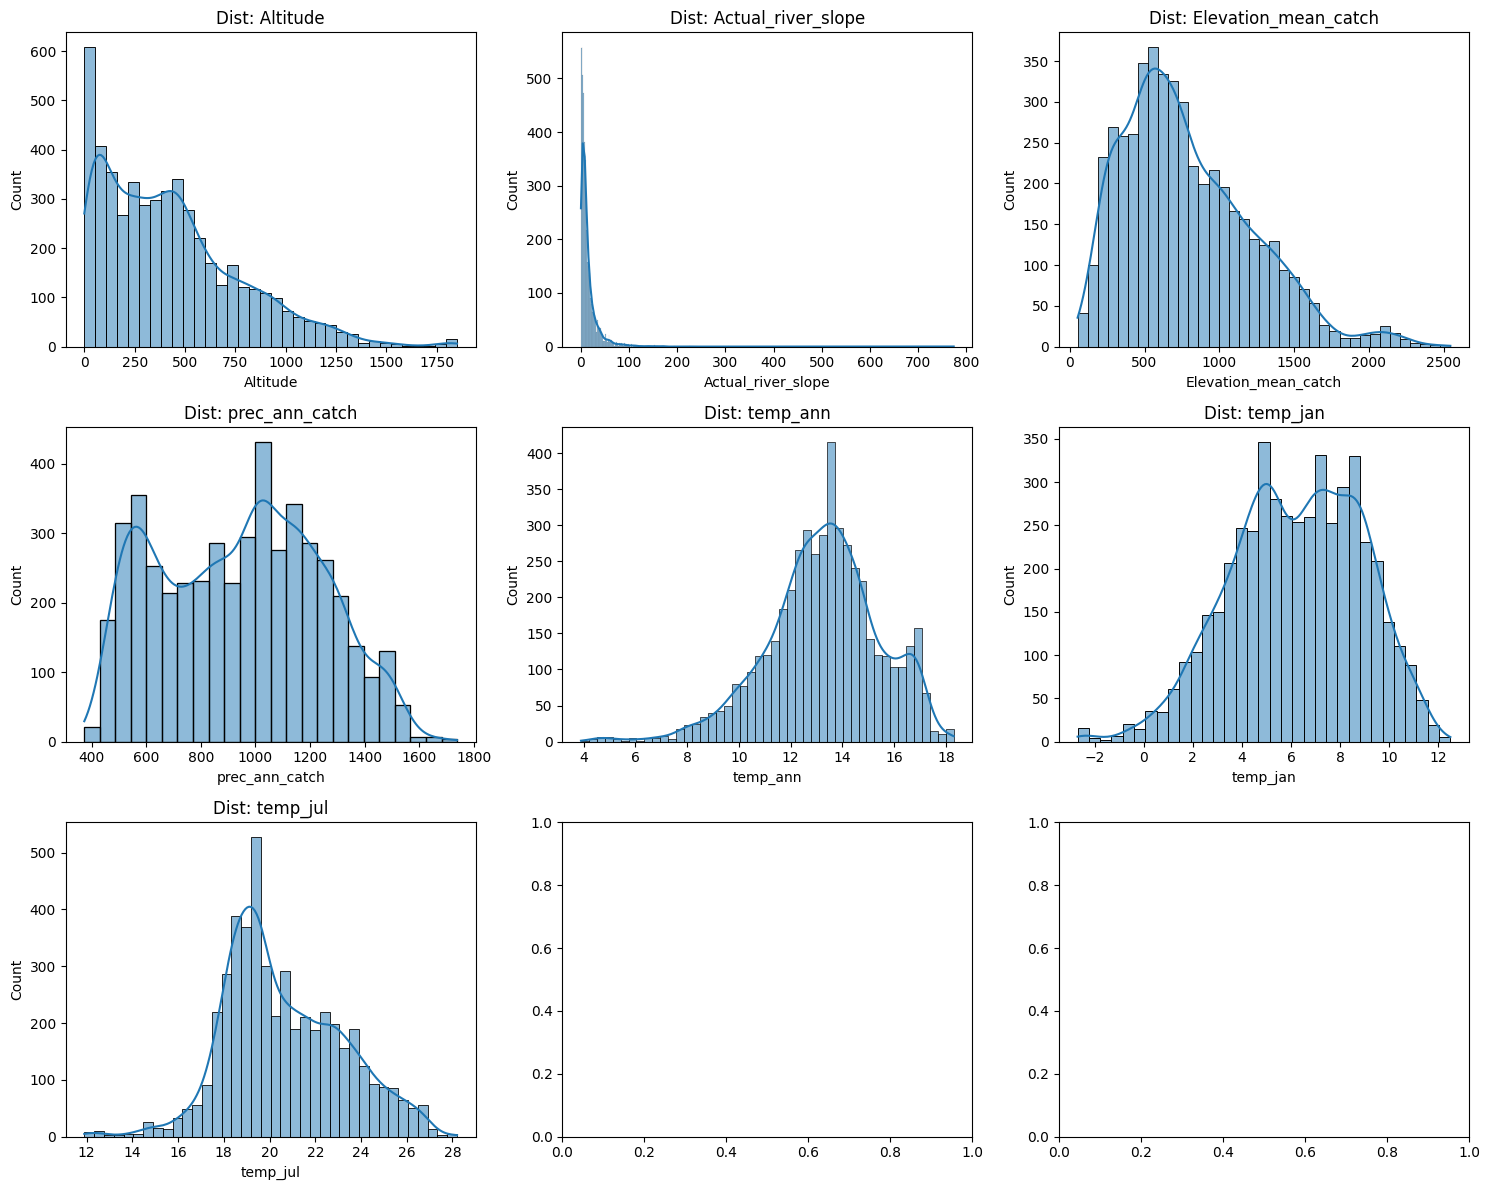

In [ ]:
vars_to_check = [
    "Altitude", "Actual_river_slope", "Elevation_mean_catch",
    "prec_ann_catch", "temp_ann", "temp_jan", "temp_jul"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

print("--- Visual check for continuous environmental variables ---")
for i, col in enumerate(vars_to_check):
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Dist: {col}')
    else:
        axes[i].set_visible(False) # Hide subplot if column not found
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping plot.")

plt.tight_layout()
plt.show()

In [ ]:
df['log_Altitude'] = np.log1p(df['Altitude'])
df['log_Slope'] = np.log1p(df['Actual_river_slope'])

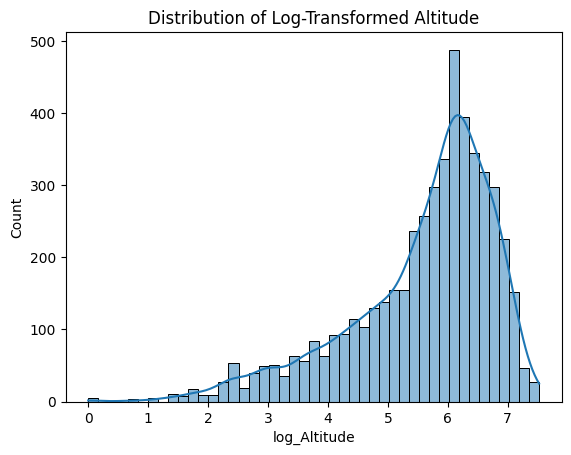

In [ ]:
sns.histplot(df['log_Altitude'], kde=True)
plt.title('Distribution of Log-Transformed Altitude')
plt.show()

In [ ]:
first_sp_idx = df.columns.get_loc("Abramis brama")
df['Richness'] = df.iloc[:, first_sp_idx:].sum(axis=1)

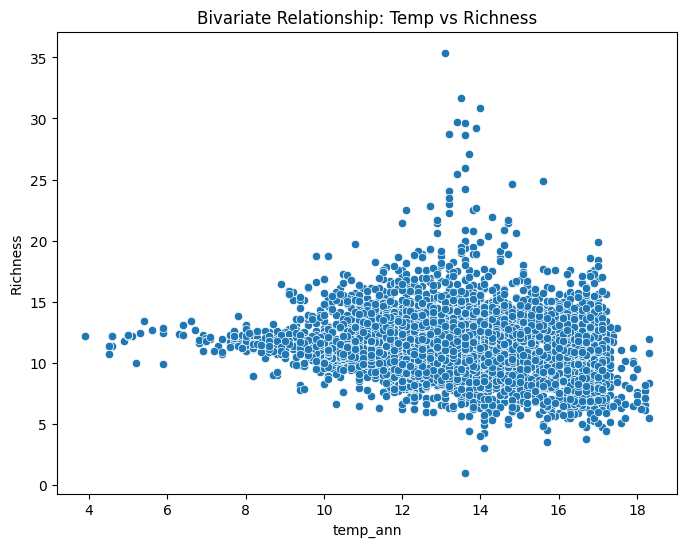

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='temp_ann', y='Richness')
plt.title('Bivariate Relationship: Temp vs Richness')
plt.show()



In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
X = df[['temp_ann', 'Richness']]
# -1 indicates an outlier, 1 indicates inlier
df['is_outlier'] = iso_forest.fit_predict(X)

In [ ]:
# --- Part 4: Visualize outliers detected by Isolation Forest ---
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='temp_ann', y='Richness', hue='is_outlier', palette={1: 'blue', -1: 'red'}, style='is_outlier', markers={1: 'o', -1: 'X'}, s=100)
plt.title('Bivariate Relationship: Temp vs Richness with Outliers')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.legend(title='Outlier Status', labels=['Inlier', 'Outlier'])
plt.show()

# Display some of the detected outliers
print("\n--- Detected Outliers (Top 5) ---")
print(df[df['is_outlier'] == -1][['temp_ann', 'Richness']].head())

# --- Part 5: Explore visually, using a single plot, if this relationship (temp_ann x species richness) may vary across countries ---
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='temp_ann', y='Richness', hue='Country', palette='viridis', alpha=0.7)
plt.title('Bivariate Relationship: Temp vs Richness across Countries')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# --- Part 4: Visualize outliers detected by Isolation Forest ---
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='temp_ann', y='Richness', hue='is_outlier', palette={1: 'blue', -1: 'red'}, style='is_outlier', markers={1: 'o', -1: 'X'}, s=100)
plt.title('Bivariate Relationship: Temp vs Richness with Outliers')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.legend(title='Outlier Status', labels=['Inlier', 'Outlier'])
plt.show()

# Display some of the detected outliers
print("\n--- Detected Outliers (Top 5) ---")
print(df[df['is_outlier'] == -1][['temp_ann', 'Richness']].head())

# --- Part 5: Explore visually the relationship (temp_ann x species richness) across countries ---
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='temp_ann', y='Richness', hue='Country', palette='viridis', alpha=0.7)
plt.title('Bivariate Relationship: Temp vs Richness across Countries')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

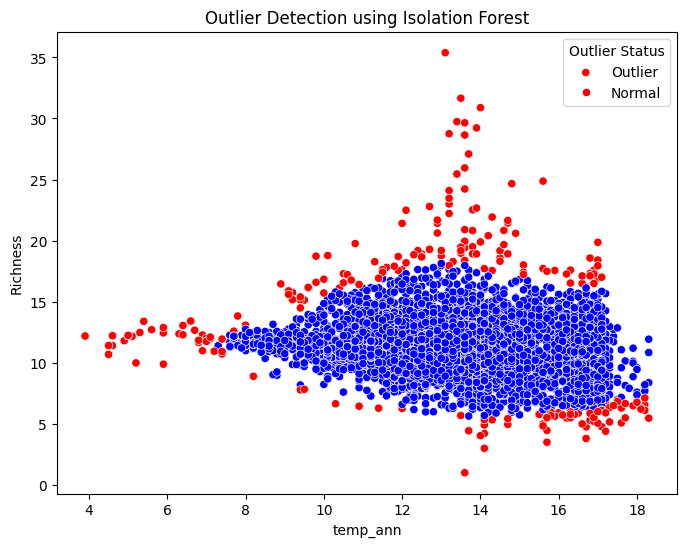

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='temp_ann', y='Richness', hue='is_outlier', palette={1: 'blue', -1: 'red'})
plt.title('Outlier Detection using Isolation Forest')
plt.legend(title='Outlier Status', labels=['Outlier', 'Normal'])
plt.show()

<Figure size 1000x600 with 0 Axes>

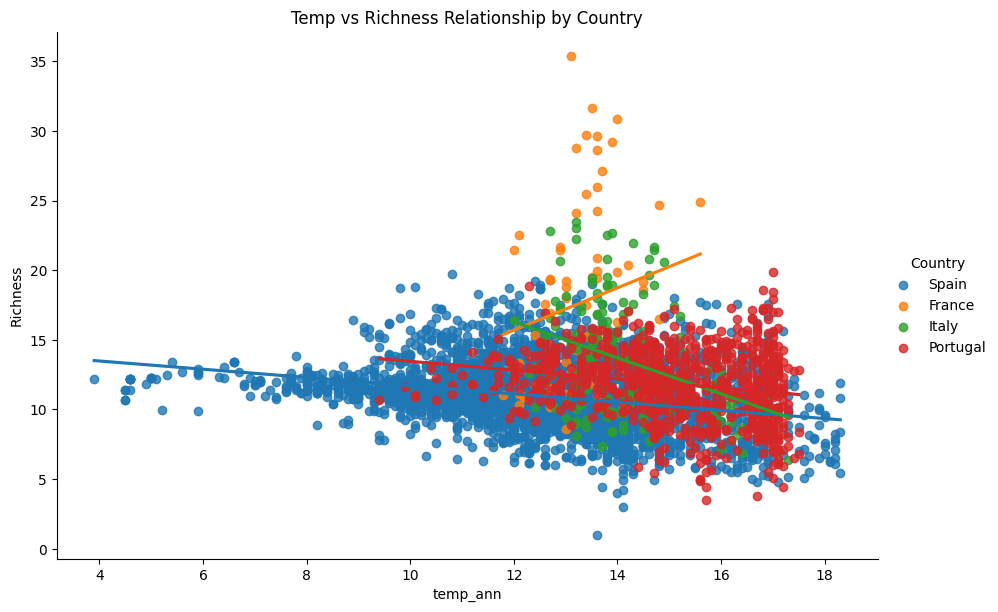

In [ ]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x='temp_ann', y='Richness', hue='Country', ci=None, height=6, aspect=1.5)
plt.title('Temp vs Richness Relationship by Country')
plt.show()